# 4D-Var State Estimation Results

While both Traditional-NPZ and PI-NPZ generate accurate forecasts when initialized from the true system state, in practice, such states are rarely known and are typically constrained only by sparse, noisy observations.
4D-Var addresses this challenge by using the model's dynamics, encoded in its tangent-linear and adjoint operators, to optimally combine prior estimates with observations.
We adopt the strong-constraint formulation, which assumes model dynamics are perfect and attributes all uncertainty to the initial state and observations.
While AD enables joint state-parameter estimation by providing gradients with respect to both states and parameters simultaneously, we focus on state estimation alone to isolate how AD-derived Jacobians perform in gradient-based optimization without the confounding effects of parameter uncertainty.
In this formulation, the goal of 4D-Var is to estimate the initial state $\mathbf{x}_0$ at time $t_0$ that minimizes a cost function $J$ composed of background and observation terms:
\begin{equation}
J(\mathbf{x}_0) = \frac{1}{2}(\mathbf{x}_0 - \mathbf{x}_b)^{\mathrm{T}}
 \mathbf{B}^{-1}(\mathbf{x}_0 - \mathbf{x}_b) + \frac{1}{2}\sum^N_{i=0}[H_i(\mathbf{x}_i) - \mathbf{y}_i]^{\mathrm{T}}
 \mathbf{R}^{-1}[H_i(\mathbf{x}_i) - \mathbf{y}_i],
\end{equation}
where $\mathbf{x}_b$ is the background (prior) state at $t_0$, $\mathbf{B}$ is the background error covariance matrix, $\mathbf{y}_i$ denotes the observations at time $t_i$, $H_i$ is the observation operator, and $\mathbf{R}$ is the observation error covariance.
Here, $H_i$ acts as a selection operator that extracts the observed components of the state vector ($N, P, Z$) at the specified times.
The optimality condition for the 4D-Var cost function requires that
\begin{equation}
\label{eq:4d_var_gradient}
\nabla_{\mathbf{x}_0} J(\mathbf{x}_0) = \mathbf{B}^{-1}(\mathbf{x}_0 - \mathbf{x}_b) + \sum_{i=0}^N \mathbf{M}_{i,0}^\text{T}\,\mathbf{H}_i^\text{T}\,\mathbf{R}_i^{-1}\,[H_i(x_i)-y_i] = 0,
\end{equation}
where $M_{i,0}$ advances the nonlinear state from $t_0$ to $t_i$, and $\mathbf{M}_{i,0}$ is its tangent-linear operator.
Similarly, $\mathbf{H}_i$ is the linearized observation operator with adjoint $\mathbf{H}_i^\text{T}$.
The sequence of tangent-linear model operators can be combined to form the adjoint model:
\begin{equation}
\mathbf{M}_{i,0}^\text{T} = \mathbf{M}_{1,0}^\text{T}\mathbf{M}_{2,1}^\text{T}\cdots\mathbf{M}_{i,i-1}^\text{T},
\end{equation}
which propagates sensitivities backward from time $t_i$ to the initial time $t_0$.

We minimize the 4D-Var cost function iteratively using a linear conjugate gradient algorithm, which updates $\mathbf{x}_0$ along search directions defined by the cost function gradient.
For Traditional-NPZ, each iteration entails a forward integration of the nonlinear NPZ model to generate the reference trajectory, a forward integration of the tangent-linear model to evaluate Jacobians along that trajectory, and a backward integration of the adjoint model to accumulate sensitivities with respect to the initial state.
In contrast, PI-NPZ obtains Jacobians directly through AD at each forecast step.
These Jacobians are cached and reused to evaluate gradients efficiently through matrix multiplications, eliminating the need for separate tangent-linear and adjoint integrations.
Embedding both models within the same 4D-Var framework therefore isolates the role of gradient computation: Traditional-NPZ relies on explicit tangent-linear and adjoint models, whereas PI-NPZ automatically supplies them once trained.

Since the practical value of these AD-derived Jacobians hinges on their accuracy in guiding 4D-Var optimization, we designed twin experiments with synthetic observations over seven-day assimilation windows, sufficient to capture NPZ dynamics while maintaining forecast skill.
We generated the truth trajectory by integrating Traditional-NPZ from the fixed reference state $\mathbf{x}$, and, as in our linearity tests, constructed 10,000 background initial states by applying Gaussian perturbations with componentwise standard deviations $(\sigma^B_N, \sigma^B_P, \sigma^B_Z)$ estimated from short-term variability in Traditional-NPZ trajectories:
\begin{equation}
\mathbf{x}_b(0) = \mathbf{x}_{\text{true}}(0) + \boldsymbol{\epsilon}, \quad \boldsymbol{\epsilon} \sim \mathcal{N}(0, \mathbf{B}),
\end{equation}
where $\mathbf{B} = \mathrm{diag}((\sigma^B_N)^2, (\sigma^B_P)^2, (\sigma^B_Z)^2)$ is the diagonal background error covariance matrix, assuming uncorrelated state errors for computational simplicity.
We tested three observation scenarios spanning various sampling conditions.
Twin Experiment 1 (T1) provides twice-daily observations of all three state variables, representing dense coverage.
Twin Experiment 2 (T2) employs irregular asynchronous sampling, with each variable receiving 2--4 observations daily at random times, introducing temporal variability.
Twin Experiment 3 (T3) adopts sparse variable-specific sampling with differential observation rates (4, 2, and 0.6 observations per day for $N$, $P$, and $Z$, respectively), reflecting unequal measurement frequencies across state variables.
In all cases, synthetic observations were generated by adding Gaussian noise with standard deviations $(\sigma^R_N, \sigma^R_P, \sigma^R_Z)$ estimated for each variable from measurement precision reported in oceanographic protocols, yielding the diagonal observation error covariance matrix:
\begin{equation}
\mathbf{R} = \mathrm{diag}\!\left((\sigma^R_N)^2, \, (\sigma^R_P)^2, \, (\sigma^R_Z)^2\right).
\end{equation}
We applied identical error covariances, observations, and convergence criteria (gradient norm $< 10^{-6}$ or 2000 iterations) to both Traditional-NPZ and PI-NPZ, ensuring a fair comparison and directly testing PI-NPZ’s gradients for 4D-Var.
All experiments converged based on the gradient criterion without reaching the iteration limit.

In [2]:
%matplotlib inline
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.ticker import AutoMinorLocator
import seaborn as sns

import numpy as np
import pandas as pd
import glob

import joblib


In [4]:
# Define parameters
min_val = "0.05"
suffix = "_frozen_params_5_384_compressed.pkl"  # or "" if not frozen

# Base path
base_dir = "../data/assimilation_results/"

# Templates for each dataset
templates = {
    "baseline": f"two_samples_per_day_xb_data_10000xb_estimates_min_guess_{min_val}{suffix}",
    "irreg_sparse": f"irregular_sparse_xb_data_10000xb_estimates_min_guess_{min_val}{suffix}",
    "field_informed": f"field_informed_xb_data_10000xb_estimates_min_guess_{min_val}{suffix}",
}

# Load dynamically
xb_dicts = {}
for name, fname in templates.items():
    fpath = os.path.join(base_dir, fname)
    if os.path.exists(fpath):
        xb_dicts[name] = joblib.load(fpath)
    else:
        print(f"File not found: {fpath}")

rows = []

for dataset_name, xb_dict in xb_dicts.items():
    for i, record in xb_dict.items():
        perturbed = record["perturbed_initial_state"]
        truth = record["truth"][0]
        diff = perturbed - truth

        row = {
            "dataset": dataset_name,
            "index": i,
            "N_perturbed": perturbed[0],
            "P_perturbed": perturbed[1],
            "Z_perturbed": perturbed[2],
            "distance_N": np.abs(perturbed[0] - truth[0]),
            "distance_P": np.abs(perturbed[1] - truth[1]),
            "distance_Z": np.abs(perturbed[2] - truth[2]),
            "distance_total_L2": np.linalg.norm(perturbed - truth),
            "distance_total_L1": np.sum(np.abs(perturbed - truth)),
            "rk4_run_time": record["rk4_run_time"],
            "pinn_run_time": record["pi_npz_run_time"],
        }
        rows.append(row)

df_xb_distances = pd.DataFrame(rows)


In [5]:
# --- Collect predictions and truth ---
pinn_preds = []
rk4_truths = []

for i, record in xb_dict.items():
    pinn_preds.append(np.array(record["pi_npz_background_state"]))  # PINN forecast
    rk4_truths.append(np.array(record["rk4_background_state"]))     # RK4 truth

pinn_preds = np.array(pinn_preds)  # shape [N, T, 3]
rk4_truths = np.array(rk4_truths)  # shape [N, T, 3]

# --- Compute PINN skill vs RK4 truth ---
pinn_scores = 1 - (np.abs(pinn_preds - rk4_truths) / np.abs(rk4_truths))

# Mean/std over all trajectories (axis=0)
pinn_mean = np.nanmean(pinn_scores, axis=0).T  # shape (3, T)
pinn_std  = np.nanstd(pinn_scores, axis=0).T

# --- Summary statistics ---
skill_mean_over_time = np.nanmean(pinn_mean, axis=1)
skill_std_over_time  = np.nanmean(pinn_std, axis=1)

global_skill_mean = np.nanmean(pinn_mean)
global_skill_std  = np.nanmean(pinn_std)

traj_skill_means = np.nanmean(pinn_scores, axis=(1,2))
traj_skill_stds  = np.nanstd(pinn_scores, axis=(1,2))

early_skill = np.nanmean(pinn_mean[:, :50], axis=1)
late_skill  = np.nanmean(pinn_mean[:, -50:], axis=1)

summary_df = pd.DataFrame({
    "Variable": ["N", "P", "Z"],
    "Mean Skill": skill_mean_over_time,
    "Std Skill": skill_std_over_time,
    "Early Skill (first 50 steps)": early_skill,
    "Late Skill (last 50 steps)": late_skill
})

# --- Print nicely ---
print("\n=== PINN Skill Summary Per Variable (vs RK4) ===")
print(summary_df.round(4))

print("\n=== Global Statistics ===")
print(f"Global mean skill: {global_skill_mean:.4f}")
print(f"Global std skill:  {global_skill_std:.4f}")

print("\n=== Trajectory Statistics ===")
print(f"Median trajectory skill: {np.nanmedian(traj_skill_means):.4f}")
print(f"Trajectory skill IQR:    {np.nanpercentile(traj_skill_means, 75) - np.nanpercentile(traj_skill_means, 25):.4f}")



=== PINN Skill Summary Per Variable (vs RK4) ===
  Variable  Mean Skill  Std Skill  Early Skill (first 50 steps)  \
0        N      0.9880     0.0046                        0.9996   
1        P      0.9971     0.0023                        0.9992   
2        Z      0.9875     0.0081                        0.9980   

   Late Skill (last 50 steps)  
0                      0.9815  
1                      0.9983  
2                      0.9896  

=== Global Statistics ===
Global mean skill: 0.9909
Global std skill:  0.0050

=== Trajectory Statistics ===
Median trajectory skill: 0.9918
Trajectory skill IQR:    0.0035


In [6]:
# === Parameters you can toggle ===
min_val = "0.05"  # switch between "0.001", "0.05", etc.
suffix  = "_5_384_compressed.pkl"  # or "_compressed.pkl"
rk4_suffix  = "_compressed.pkl"  # or "_compressed.pkl"

base_path = "../data/assimilation_results/"

# === Template builder ===
file_info = [
    ("baseline",      "PI-NPZ",          f"two_samples_per_day_pi_npz_frozen_params_assimilation_10000xb_estimates_min_guess_{min_val}_2000{suffix}"),
    ("baseline",      "Traditional-NPZ", f"two_samples_per_day_rk4_assimilation_10000xb_estimates_min_guess_{min_val}_2000{rk4_suffix}"),

    ("irreg_sparse",  "PI-NPZ",          f"irregular_sparse_pi_npz_frozen_params_assimilation_10000xb_estimates_min_guess_{min_val}_2000{suffix}"),
    ("irreg_sparse",  "Traditional-NPZ", f"irregular_sparse_rk4_assimilation_10000xb_estimates_min_guess_{min_val}_2000{rk4_suffix}"),

    ("field_informed","PI-NPZ",          f"field_informed_pi_npz_frozen_assimilation_10000xb_estimates_min_guess_{min_val}_2000{suffix}"),
    ("field_informed","Traditional-NPZ", f"field_informed_rk4_assimilation_10000xb_estimates_min_guess_{min_val}_2000{rk4_suffix}"),
]

# === Map prefixes for consistent key lookup ===
prefix_map = {
    "PI-NPZ": "pi_npz",
    "Traditional-NPZ": "rk4",
}

# === Build DataFrame ===
records = []
for dataset_label, method, filename in file_info:
    path = os.path.join(base_path, filename)
    if not os.path.exists(path):
        print(f"Missing file: {path}")
        continue

    data = joblib.load(path)
    prefix = prefix_map[method]

    for i, result in data.items():
        record = {
            "dataset": dataset_label,
            "method": method,
            "index": i,
            "jo_b": result.get(f"jo_b_{prefix}"),
            "jb_b": result.get(f"jb_b_{prefix}"),
            "J_total_b": result.get(f"J_total_b_{prefix}"),
            "jo_a": result.get(f"jo_a_{prefix}"),
            "jb_a": result.get(f"jb_a_{prefix}"),
            "J_total_a": result.get(f"J_total_a_{prefix}"),
            "misfitb": result.get(f"{prefix}_misfitb"),
            "misfita": result.get(f"{prefix}_misfita"),
            "Improvement": result.get(f"Improvement_{prefix}", result.get("Improvement")),
            "pct_drop_J": result.get(f"pct_drop_J_{prefix}"),
            "pct_drop_Jo": result.get(f"pct_drop_Jo_{prefix}"),
            "pct_drop_Jb": result.get(f"pct_drop_Jb_{prefix}"),
            "cg_iterations": result.get(f"cg_iterations_{prefix}"),
            "converged": result.get(f"converged_{prefix}"),
            "exit_code": result.get(f"exit_code_{prefix}"),
            "runtime": result.get(f"{prefix}_time"),
            # NEW: store trajectories
            "xa": result.get(f"xa_{prefix}"),
            "xb": result.get(f"xb_{prefix}"),
        }
        records.append(record)

df_flat = pd.DataFrame.from_records(records)


In [7]:
# Check convergence counts by method
print(df_flat.groupby("method")["converged"].value_counts())

# Or check proportion converged per method
print(df_flat.groupby("method")["converged"].mean())

# If you just want a yes/no answer:
for method, subdf in df_flat.groupby("method"):
    all_converged = subdf["converged"].all()
    print(f"{method}: all converged? {all_converged}")


method           converged
PI-NPZ           1            30000
Traditional-NPZ  1            30000
Name: count, dtype: int64
method
PI-NPZ             1.0
Traditional-NPZ    1.0
Name: converged, dtype: float64
PI-NPZ: all converged? True
Traditional-NPZ: all converged? True


In [8]:
# Add a log-transformed runtime column before melt
df_flat["log_runtime"] = np.log10(df_flat["runtime"])
df_flat["jo_jb_ratio"] = df_flat["jo_a"] / df_flat["jb_a"]
df_flat["log_jo_jb_ratio"] = np.log10(df_flat["jo_jb_ratio"])
df_flat["pct_drop_J_100"] = 100 * df_flat["pct_drop_J"]

# Update metrics list
metrics = ["log_runtime", "pct_drop_J_100", "log_jo_jb_ratio", "Improvement"]

# Melt for plotting
df_long = df_flat.melt(
    id_vars=["method", "dataset"],
    value_vars=metrics,
    var_name="metric",
    value_name="value"
)

# Nice labels
df_long["metric"] = df_long["metric"].replace({
    "log_runtime": "log10(Runtime)",
    "log_jo_jb_ratio": "log10(jo_a / jb_a)"
})


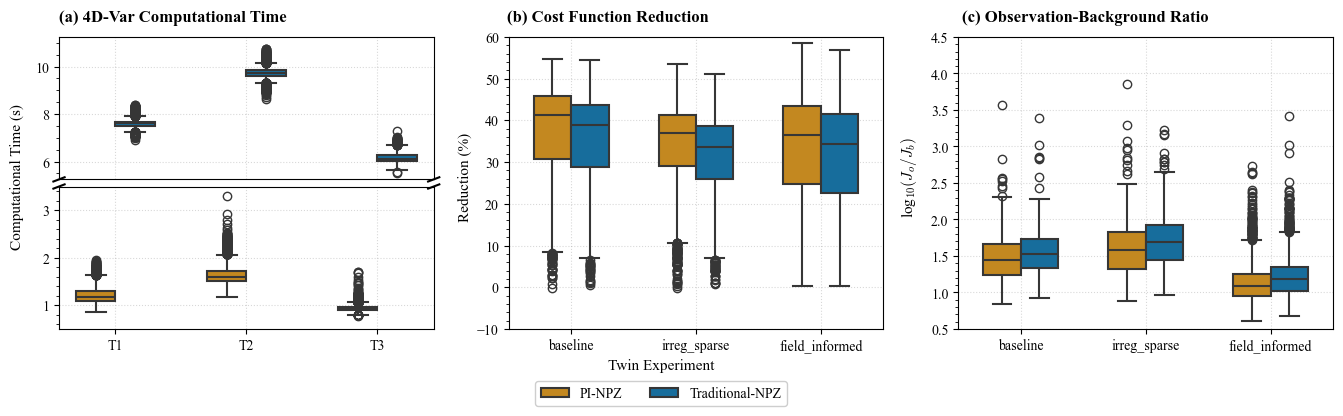

In [9]:
# === Keep only 3 metrics (drop Improvement) ===
metrics_normal = ["runtime", "pct_drop_J_100", "log_jo_jb_ratio"]

df_long_normal = df_flat.melt(
    id_vars=["method", "dataset"],
    value_vars=metrics_normal,
    var_name="metric",
    value_name="value"
)

# === Relabel metrics ===
df_long_normal["metric"] = df_long_normal["metric"].replace({
    "runtime": "Computational Time (s)",
    "pct_drop_J_100": "Cost Function Reduction (%)",
    "log_jo_jb_ratio": "log$_{10}(J_o/J_b)$"
})

# === Typography ===
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# === Colors ===
trad_npz_color = "#0173B2"   # Traditional-NPZ (orange)
pinn_color     =  "#DE8F05"  # PI-NPZ (blue)
method_palette = {"Traditional-NPZ": trad_npz_color, "PI-NPZ": pinn_color}


# --- Runtime subset ---
df_runtime = df_long_normal[df_long_normal["metric"] == "Computational Time (s)"]

# --- Create figure with GridSpec ---
fig = plt.figure(figsize=(14, 4))
gs = gridspec.GridSpec(2, 3, figure=fig,
                       left=0.07, right=0.98,
                       top=0.88, bottom=0.15,
                       wspace=0.2, hspace=0.05)

panel_labels = ["(a)", "(b)", "(c)"]

# =========================================================
# (a) Assimilation Runtime (broken axis)
# =========================================================
ax_top = fig.add_subplot(gs[0, 0])
sns.boxplot(data=df_runtime, x="dataset", y="value", hue="method",
            palette=method_palette, width=0.6, linewidth=1.5, ax=ax_top)
ax_top.set_ylim(5.25, 11.25)
ax_top.set_ylabel(""); ax_top.set_xlabel("")
ax_top.tick_params(labelbottom=False, bottom=False, labelsize=10)
ax_top.grid(True, linestyle=":", alpha=0.3, color="gray")
ax_top.yaxis.set_minor_locator(AutoMinorLocator())
if ax_top.get_legend() is not None:
    ax_top.get_legend().remove()

ax_bottom = fig.add_subplot(gs[1, 0], sharex=ax_top)
sns.boxplot(data=df_runtime, x="dataset", y="value", hue="method",
            palette=method_palette, width=0.6, linewidth=1.5, ax=ax_bottom)
ax_bottom.set_ylim(0.5, 3.5)
ax_bottom.set_xlabel(""); ax_bottom.set_ylabel("")
ax_bottom.set_xticks(range(3))
ax_bottom.set_xticklabels(["T1", "T2", "T3"])
ax_bottom.grid(True, linestyle=":", alpha=0.3, color="gray")
ax_bottom.tick_params(labelsize=10)
ax_bottom.yaxis.set_minor_locator(AutoMinorLocator())
if ax_bottom.get_legend() is not None:
    ax_bottom.get_legend().remove()

# Break marks
d = .015
for ax, pos in [(ax_bottom, 1), (ax_top, 0)]:
    kwargs = dict(transform=ax.transAxes, color='k', clip_on=False)
    ax.plot((-d, +d), (pos-d, pos+d), **kwargs)
    ax.plot((1-d, 1+d), (pos-d, pos+d), **kwargs)

# =========================================================
# (b) Cost Reduction
# =========================================================
metric_data = df_long_normal[df_long_normal["metric"] == "Cost Function Reduction (%)"]
ax_b = fig.add_subplot(gs[:, 1])
sns.boxplot(data=metric_data, x="dataset", y="value", hue="method",
            palette=method_palette, width=0.6, linewidth=1.5, ax=ax_b)
ax_b.set_ylabel(""); ax_b.set_xlabel("")
ax_bottom.set_xticks(range(3))
ax_bottom.set_xticklabels(["T1", "T2", "T3"])
ax_b.grid(True, linestyle=":", alpha=0.3, color="gray")
ax_b.tick_params(labelsize=10)
ax_b.yaxis.set_minor_locator(AutoMinorLocator())
ax_b.set_ylim(-10, 60)
if ax_b.get_legend() is not None:
    ax_b.get_legend().remove()

# =========================================================
# (c) Observation Weight
# =========================================================
metric_data = df_long_normal[df_long_normal["metric"] == "log$_{10}(J_o/J_b)$"]
ax_c = fig.add_subplot(gs[:, 2])
sns.boxplot(data=metric_data, x="dataset", y="value", hue="method",
            palette=method_palette, width=0.6, linewidth=1.5, ax=ax_c)
ax_c.set_ylabel(""); ax_c.set_xlabel("")
ax_bottom.set_xticks(range(3))
ax_bottom.set_xticklabels(["T1", "T2", "T3"])
ax_c.grid(True, linestyle=":", alpha=0.3, color="gray")
ax_c.tick_params(labelsize=10)
ax_c.yaxis.set_minor_locator(AutoMinorLocator())
ax_c.set_ylim(0.5, 4.5)
if ax_c.get_legend() is not None:
    ax_c.get_legend().remove()

# =========================================================
# Panel Titles
# =========================================================
fig.text(0.07, 0.91, f"{panel_labels[0]} 4D-Var Computational Time",
         fontsize=12, fontweight='bold', ha='left', va='bottom')
fig.text(0.39, 0.91, f"{panel_labels[1]} Cost Function Reduction",
         fontsize=12, fontweight='bold', ha='left', va='bottom')
fig.text(0.715, 0.91, f"{panel_labels[2]} Observation-Background Ratio",
         fontsize=12, fontweight='bold', ha='left', va='bottom')

# =========================================================
# Figure-level y-labels
# =========================================================
fig.text(0.035, 0.53, "Computational Time (s)", fontsize=11, va='center', rotation='vertical')
fig.text(0.355, 0.53, "Reduction (%)", fontsize=11, va='center', rotation='vertical')
fig.text(0.67, 0.53, "log$_{10}(J_o/J_b)$", fontsize=11, va='center', rotation='vertical')

# Shared x-label
fig.text(0.5, 0.05, "Twin Experiment", fontsize=11, ha='center')

# =========================================================
# Shared Legend
# =========================================================
handles, labels = ax_bottom.get_legend_handles_labels()
fig.legend(handles, labels,
           loc='lower center', ncol=2,
           fontsize=10, framealpha=0.95,
           bbox_to_anchor=(0.5, -0.06))

# === Save ===
# base_path = "/Users/egank31/Documents/Documents - Otto/GitHub/pinns/npz/current/important_files_paper/figures/"
# file_base = "state_estimation_boxplots_broken_axis"

# for ext in ["pdf"]:
#     dpi = 600 if ext == "png" else None
#     plt.savefig(f"{base_path}{file_base}.{ext}",
#                 dpi=dpi, bbox_inches='tight',
#                 pad_inches=0.02, format=ext)

plt.show()


In [10]:
# ============================================================================
# Calculate boxplot statistics for writing
# ============================================================================

print("\n" + "="*70)
print("BOXPLOT STATISTICS FOR MANUSCRIPT")
print("="*70)

# --- Panel (a): Computational Time ---
print("\n(a) Computational Time (seconds):")
for method in ["Traditional-NPZ", "PI-NPZ"]:
    method_data = df_flat[df_flat["method"] == method]["runtime"]
    print(f"\n{method}:")
    print(f"  Median: {method_data.median():.2f} s")
    print(f"  Mean: {method_data.mean():.2f} s")
    print(f"  Range: [{method_data.min():.2f}, {method_data.max():.2f}] s")  # ADD THIS
    print(f"  IQR: [{method_data.quantile(0.25):.2f}, {method_data.quantile(0.75):.2f}] s")
    
    # By experiment
    for exp in ["baseline", "irreg_sparse", "field_informed"]:
        exp_data = df_flat[(df_flat["method"] == method) & (df_flat["dataset"] == exp)]["runtime"]
        print(f"  {exp}: median = {exp_data.median():.2f} s")

# Speedup
trad_median = df_flat[df_flat["method"] == "Traditional-NPZ"]["runtime"].median()
pinn_median = df_flat[df_flat["method"] == "PI-NPZ"]["runtime"].median()
speedup = trad_median / pinn_median
print(f"\nSpeedup factor: {speedup:.1f}×")

# --- Panel (b): Cost Function Reduction ---
print("\n(b) Cost Function Reduction (%):")
for method in ["Traditional-NPZ", "PI-NPZ"]:
    method_data = df_flat[df_flat["method"] == method]["pct_drop_J_100"]
    print(f"\n{method}:")
    print(f"  Median: {method_data.median():.1f}%")
    print(f"  Mean: {method_data.mean():.1f}%")
    print(f"  Range: [{method_data.min():.1f}%, {method_data.max():.1f}%]")
    print(f"  IQR: [{method_data.quantile(0.25):.1f}%, {method_data.quantile(0.75):.1f}%]")
    
    # By experiment
    for exp in ["baseline", "irreg_sparse", "field_informed"]:
        exp_data = df_flat[(df_flat["method"] == method) & (df_flat["dataset"] == exp)]["pct_drop_J_100"]
        print(f"  {exp}: median = {exp_data.median():.1f}%")

# Difference between methods
trad_cost = df_flat[df_flat["method"] == "Traditional-NPZ"]["pct_drop_J_100"]
pinn_cost = df_flat[df_flat["method"] == "PI-NPZ"]["pct_drop_J_100"]
print(f"\nMedian difference (Trad - PINN): {trad_cost.median() - pinn_cost.median():.2f} percentage points")

# --- Panel (c): Observation-Background Ratio ---
print("\n(c) log₁₀(Jo/Jb) Ratio:")
for method in ["Traditional-NPZ", "PI-NPZ"]:
    method_data = df_flat[df_flat["method"] == method]["log_jo_jb_ratio"]
    print(f"\n{method}:")
    print(f"  Median: {method_data.median():.2f}")
    print(f"  Mean: {method_data.mean():.2f}")
    print(f"  Range: [{method_data.min():.2f}, {method_data.max():.2f}]")
    print(f"  IQR: [{method_data.quantile(0.25):.2f}, {method_data.quantile(0.75):.2f}]")
    
    # By experiment
    for exp in ["baseline", "irreg_sparse", "field_informed"]:
        exp_data = df_flat[(df_flat["method"] == method) & (df_flat["dataset"] == exp)]["log_jo_jb_ratio"]
        print(f"  {exp}: median = {exp_data.median():.2f}")

# Difference between methods
trad_ratio = df_flat[df_flat["method"] == "Traditional-NPZ"]["log_jo_jb_ratio"]
pinn_ratio = df_flat[df_flat["method"] == "PI-NPZ"]["log_jo_jb_ratio"]
print(f"\nMedian difference (Trad - PINN): {trad_ratio.median() - pinn_ratio.median():.3f}")

# --- Outlier Analysis (BY EXPERIMENT) ---
print("\n" + "="*70)
print("OUTLIER ANALYSIS (BY EXPERIMENT)")
print("="*70)

for metric_name, metric_col in [("Computational Time (seconds)", "runtime"),
                                ("Cost Reduction", "pct_drop_J_100"), 
                                ("log₁₀(Jo/Jb)", "log_jo_jb_ratio")]:
    print(f"\n{metric_name}:")
    
    total_outliers_per_method = {"Traditional-NPZ": 0, "PI-NPZ": 0}
    total_points_per_method = {"Traditional-NPZ": 0, "PI-NPZ": 0}
    
    for method in ["Traditional-NPZ", "PI-NPZ"]:
        print(f"\n  {method}:")
        
        for exp in ["baseline", "irreg_sparse", "field_informed"]:
            # Get data for this specific experiment
            data = df_flat[(df_flat["method"] == method) & 
                          (df_flat["dataset"] == exp)][metric_col]
            
            Q1 = data.quantile(0.25)
            Q3 = data.quantile(0.75)
            IQR = Q3 - Q1
            lower_fence = Q1 - 1.5 * IQR
            upper_fence = Q3 + 1.5 * IQR
            
            outliers = data[(data < lower_fence) | (data > upper_fence)]
            
            exp_name = {"baseline": "T1", "irreg_sparse": "T2", "field_informed": "T3"}[exp]
            print(f"    {exp_name}: {len(outliers)} outliers out of {len(data)} ({len(outliers)/len(data)*100:.2f}%)")
            
            total_outliers_per_method[method] += len(outliers)
            total_points_per_method[method] += len(data)
        
        # Print totals for this method
        total_outliers = total_outliers_per_method[method]
        total_points = total_points_per_method[method]
        print(f"    TOTAL: {total_outliers} outliers out of {total_points} ({total_outliers/total_points*100:.2f}%)")

print("\n" + "="*70)



BOXPLOT STATISTICS FOR MANUSCRIPT

(a) Computational Time (seconds):

Traditional-NPZ:
  Median: 7.61 s
  Mean: 7.83 s
  Range: [5.53, 10.74] s
  IQR: [6.29, 9.63] s
  baseline: median = 7.61 s
  irreg_sparse: median = 9.73 s
  field_informed: median = 6.11 s

PI-NPZ:
  Median: 1.17 s
  Mean: 1.26 s
  Range: [0.78, 3.29] s
  IQR: [0.96, 1.52] s
  baseline: median = 1.17 s
  irreg_sparse: median = 1.60 s
  field_informed: median = 0.93 s

Speedup factor: 6.5×

(b) Cost Function Reduction (%):

Traditional-NPZ:
  Median: 35.4%
  Mean: 33.6%
  Range: [0.2%, 56.8%]
  IQR: [25.6%, 41.5%]
  baseline: median = 38.9%
  irreg_sparse: median = 33.6%
  field_informed: median = 34.4%

PI-NPZ:
  Median: 38.1%
  Mean: 35.9%
  Range: [-0.2%, 58.6%]
  IQR: [28.0%, 43.7%]
  baseline: median = 41.4%
  irreg_sparse: median = 36.9%
  field_informed: median = 36.6%

Median difference (Trad - PINN): -2.66 percentage points

(c) log₁₀(Jo/Jb) Ratio:

Traditional-NPZ:
  Median: 1.45
  Mean: 1.47
  Range: [0.6

In [11]:
# === Step 1. Grab one truth trajectory (same across experiments) ===
example_dataset = list(xb_dicts.values())[0]
example_record = list(example_dataset.values())[0]
truth = example_record["truth"]   # shape (T, 3)

# === Step 2. Compute skill scores for each dataset/method ===
skill_results = []

for dataset_name, group in df_flat.groupby("dataset"):
    for method_name, sub in group.groupby("method"):
        xa_list = sub["xa"].dropna().values  # list of arrays
        if len(xa_list) == 0:
            continue

        xa_array = np.stack(xa_list, axis=0)  # shape: (N, T, 3)

        # Broadcast truth to match (N,T,3)
        truth_array = np.broadcast_to(truth, xa_array.shape)

        # Skill score: 1 - |xa - truth| / |truth|
        skill_scores = 1 - (np.abs(xa_array - truth_array) / np.abs(truth_array))

        # Aggregate over variables
        total_skill_per_trajectory = np.nanmean(skill_scores, axis=2)  # (N,T)

        # Time-series mean/std across trajectories
        total_skill_mean = np.nanmean(total_skill_per_trajectory, axis=0)  # (T,)
        total_skill_std  = np.nanstd(total_skill_per_trajectory, axis=0)   # (T,)

        # Global skill: mean over all time + trajectories
        global_skill = np.nanmean(total_skill_per_trajectory)

        skill_results.append({
            "dataset": dataset_name,
            "method": method_name,
            "skill_mean": total_skill_mean,
            "skill_std": total_skill_std,
            "global_skill": global_skill,
        })

# === Step 3. Convert to summary DataFrame ===
summary_rows = [
    {"dataset": r["dataset"], "method": r["method"], "global_skill": r["global_skill"]}
    for r in skill_results
]
df_skills = pd.DataFrame(summary_rows)

# === Step 4. Print results ===
print("\n=== Global Skill Scores ===")
print(df_skills)



=== Global Skill Scores ===
          dataset           method  global_skill
0        baseline           PI-NPZ      0.891787
1        baseline  Traditional-NPZ      0.889388
2  field_informed           PI-NPZ      0.894714
3  field_informed  Traditional-NPZ      0.892432
4    irreg_sparse           PI-NPZ      0.888689
5    irreg_sparse  Traditional-NPZ      0.885840


In [18]:
# === Recalculate skill aggregated across ALL experiments ===
example_dataset = list(xb_dicts.values())[0]
example_record = list(example_dataset.values())[0]
truth = example_record["truth"]

aggregated_skills = {}
for method in ["PI-NPZ", "Traditional-NPZ"]:
    all_trajectories = []
    
    # Collect ALL xa trajectories for this method across all datasets
    for dataset_name in df_flat["dataset"].unique():
        subset = df_flat[(df_flat["dataset"] == dataset_name) & 
                        (df_flat["method"] == method)]
        xa_list = subset["xa"].dropna().values
        
        if len(xa_list) > 0:
            xa_array = np.stack(xa_list, axis=0)  # (N, T, 3)
            all_trajectories.append(xa_array)
    
    # Stack all trajectories across datasets
    all_xa = np.concatenate(all_trajectories, axis=0)  # (N_total, T, 3)
    
    # Compute skill vs truth
    truth_array = np.broadcast_to(truth, all_xa.shape)
    skill_scores = 1 - (np.abs(all_xa - truth_array) / np.abs(truth_array))
    
    # Aggregate over variables
    skill_per_traj = np.nanmean(skill_scores, axis=2)  # (N_total, T)
    
    # Overall mean and std across all trajectories at each time
    skill_mean = np.nanmean(skill_per_traj, axis=0)  # (T,)
    skill_std = np.nanstd(skill_per_traj, axis=0)    # (T,)
    
    # Global skill for each trajectory (averaged over time)
    global_skill_per_traj = np.nanmean(skill_per_traj, axis=1)  # (N_total,)
    
    # Mean and std of global skill
    global_skill_mean = np.nanmean(global_skill_per_traj)
    global_skill_std = np.nanstd(global_skill_per_traj)
    
    aggregated_skills[method] = {
        "mean": skill_mean,              # Time series of mean skill
        "std": skill_std,                # Time series of std skill
        "global_mean": global_skill_mean,  # Single number: mean of time-averaged skill
        "global_std": global_skill_std     # Single number: std of time-averaged skill
    }

# Print results for text
print("\nAnalysis forecast skill summary:")
for method in ["Traditional-NPZ", "PI-NPZ"]:
    mean = aggregated_skills[method]["global_mean"]
    std = aggregated_skills[method]["global_std"]
    print(f"{method}: {mean:.3f} ± {std:.3f} ({mean*100:.1f}% ± {std*100:.1f}%)")

# Calculate difference
trad_mean = aggregated_skills["Traditional-NPZ"]["global_mean"]
pinn_mean = aggregated_skills["PI-NPZ"]["global_mean"]
diff = pinn_mean - trad_mean
print(f"\nDifference (PI-NPZ - Traditional): {diff:.4f} ({diff*100:.2f} percentage points)")



Analysis forecast skill summary:
Traditional-NPZ: 0.889 ± 0.059 (88.9% ± 5.9%)
PI-NPZ: 0.892 ± 0.058 (89.2% ± 5.8%)

Difference (PI-NPZ - Traditional): 0.0025 (0.25 percentage points)


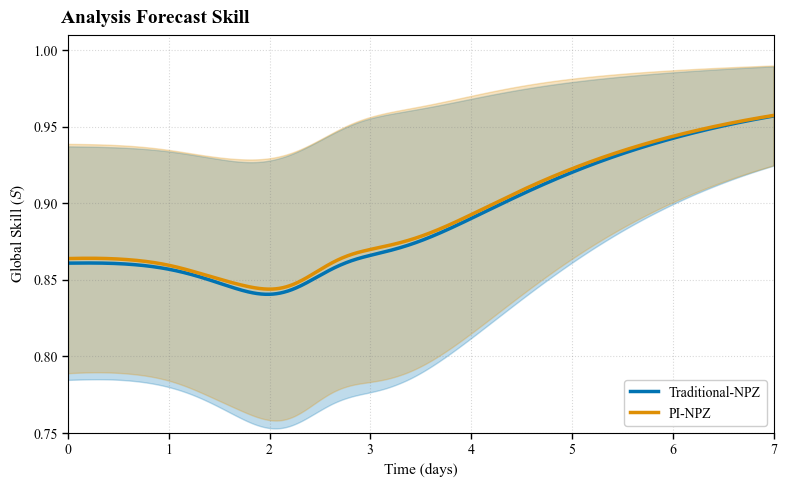


Analysis Forecast Skill Summary:
Traditional-NPZ: 0.8892 ± 0.0594
PI-NPZ: 0.8917 ± 0.0580
Difference: 0.0025 (0.25 percentage points)

Minimum skill scores:
Traditional-NPZ: 0.8404 at day 1.98
PI-NPZ: 0.8438 at day 2.00


In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Typography for JAMES publication
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = 11
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['xtick.top'] = False
plt.rcParams['ytick.right'] = False

# Axis and tick styling
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'
plt.rcParams['text.color'] = 'black'

# Color scheme
colors = {"PI-NPZ": "#DE8F05", "Traditional-NPZ": "#0173B2"}

# === Get time array ===
T = len(aggregated_skills["PI-NPZ"]["mean"])
times = np.linspace(0, 7, T)

# === Single-panel figure ===
fig, ax = plt.subplots(figsize=(8, 5))

# Plot both methods
for method in ["Traditional-NPZ", "PI-NPZ"]:
    result = aggregated_skills[method]
    mean = result["mean"]
    std = result["std"]
    
    lower = np.clip(mean - std, 0.0, None)
    upper = np.minimum(mean + std, 1.0)
    
    ax.plot(times, mean, color=colors[method], linewidth=2.5, 
            label=method)
    ax.fill_between(times, lower, upper, color=colors[method], 
                    alpha=0.25)

# Labels
ax.set_xlabel("Time (days)", fontsize=11)
ax.set_ylabel("Global Skill ($S$)", fontsize=11)

# Set axis limits
ax.set_xlim(0, 7)
ax.set_ylim(0.75, 1.01)

# Grid (subtle)
ax.grid(True, linestyle=':', alpha=0.3, color='gray')
ax.tick_params(direction='out', length=4, width=1, color='black')

# Add legend
ax.legend(loc='lower right', fontsize=10, framealpha=0.95)

# Title
ax.text(-0.01, 1.02, 'Analysis Forecast Skill', transform=ax.transAxes,
        fontsize=14, fontweight='bold', ha='left', va='bottom')

# Add summary statistics box
trad_mean = aggregated_skills["Traditional-NPZ"]["global_mean"]
trad_std = aggregated_skills["Traditional-NPZ"]["global_std"]
pinn_mean = aggregated_skills["PI-NPZ"]["global_mean"]
pinn_std = aggregated_skills["PI-NPZ"]["global_std"]

plt.tight_layout()

# === Save in multiple formats ===
# base_path = "../figures/"
# file_base = "analysis_forecast_skill_comparison"

# for ext in ["pdf"]:
#     dpi = 600 if ext == "png" else None
#     plt.savefig(f"{base_path}{file_base}.{ext}", 
#                 dpi=dpi, 
#                 bbox_inches='tight', 
#                 pad_inches=0.02,
#                 format=ext)

plt.show()

# === Print Summary ===
print(f"\nAnalysis Forecast Skill Summary:")
print(f"Traditional-NPZ: {trad_mean:.4f} ± {trad_std:.4f}")
print(f"PI-NPZ: {pinn_mean:.4f} ± {pinn_std:.4f}")
print(f"Difference: {pinn_mean - trad_mean:.4f} ({(pinn_mean - trad_mean)*100:.2f} percentage points)")

print(f"\nMinimum skill scores:")
trad_min_idx = np.argmin(aggregated_skills["Traditional-NPZ"]["mean"])
pinn_min_idx = np.argmin(aggregated_skills["PI-NPZ"]["mean"])
print(f"Traditional-NPZ: {aggregated_skills['Traditional-NPZ']['mean'][trad_min_idx]:.4f} at day {times[trad_min_idx]:.2f}")
print(f"PI-NPZ: {aggregated_skills['PI-NPZ']['mean'][pinn_min_idx]:.4f} at day {times[pinn_min_idx]:.2f}")
